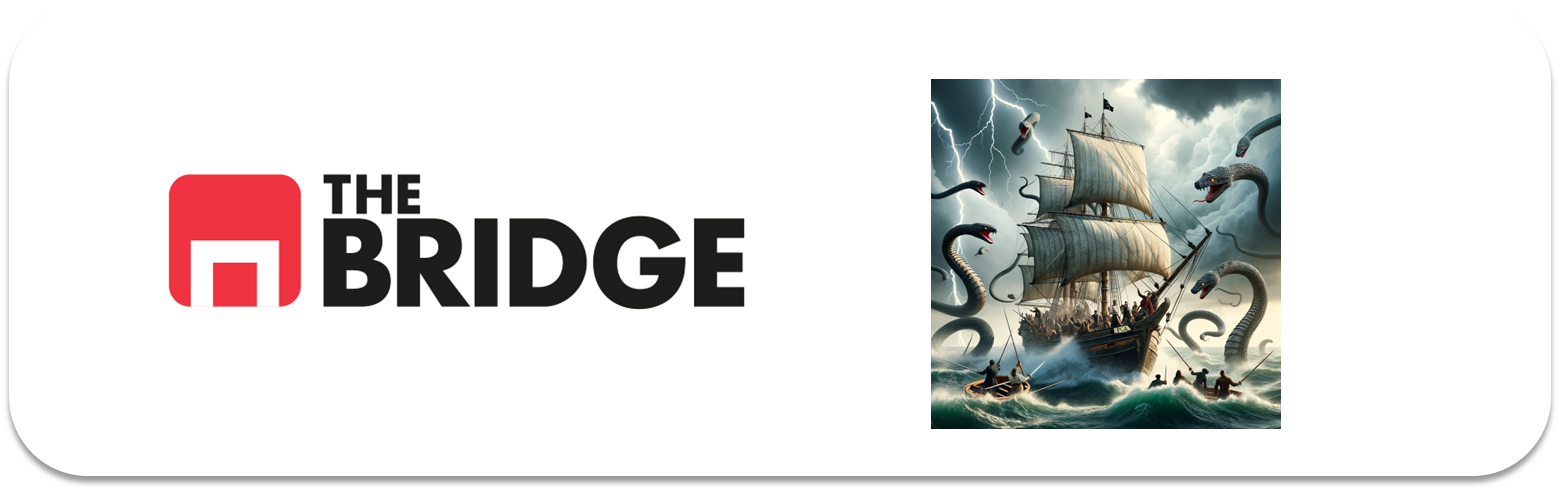

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, classification_report

from scipy import stats
from scipy.stats import pointbiserialr
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.feature_selection import RFECV
from catboost import CatBoostClassifier
from sklearn.decomposition import PCA

from toolbox_ml.eda.core import (
    describe_df, tipifica_variables, 
    get_features_num_regression, 
    plot_features_num_regression, 
    get_features_cat_regression, 
    plot_features_cat_regression
)

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [3]:
df = pd.read_csv("./data/credit_npo.csv")
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [5]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
SeriousDlqin2yrs,int64,0.0,2,0.02
RevolvingUtilizationOfUnsecuredLines,float64,0.0,10764,85.86
age,int64,0.0,78,0.62
NumberOfTime30-59DaysPastDueNotWorse,int64,0.0,10,0.08
DebtRatio,float64,0.0,11547,92.1
MonthlyIncome,float64,5.75,4167,33.24
NumberOfOpenCreditLinesAndLoans,int64,0.0,43,0.34
NumberOfTimes90DaysLate,int64,0.0,13,0.1
NumberRealEstateLoansOrLines,int64,0.0,16,0.13
NumberOfTime60-89DaysPastDueNotWorse,int64,0.0,8,0.06


In [6]:
tipifica_variables(df, umbral_categoria=16, umbral_continua=30)

,nombre_variable,tipo_sugerido
0,SeriousDlqin2yrs,Binaria
1,RevolvingUtilizationOfUnsecuredLines,Numérica Continua
2,age,Numérica Discreta
3,NumberOfTime30-59DaysPastDueNotWorse,Categórica
4,DebtRatio,Numérica Continua
5,MonthlyIncome,Numérica Continua
6,NumberOfOpenCreditLinesAndLoans,Numérica Discreta
7,NumberOfTimes90DaysLate,Categórica
8,NumberRealEstateLoansOrLines,Numérica Discreta
9,NumberOfTime60-89DaysPastDueNotWorse,Categórica


In [7]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


In [8]:
# ── 1a. Eliminar filas con nulos ─────────────────────────────
df = df.dropna().reset_index(drop=True)
print("Shape después de eliminar nulos:", df.shape)

Shape después de eliminar nulos: (11816, 11)


In [9]:
# ── 1b. Categorización de columnas NumberOf... ───────────────

# Veces en mora (30-59, 60-89, 90+):
# Mayoría absoluta en 0; valores 98 son errores → absorber en '1+'
cols_mora = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate',
             'NumberOfTime60-89DaysPastDueNotWorse']

for col in cols_mora:
    df[col]=pd.cut(df[col], 
                   bins=[-1, 0, df[col].max()],
                   labels=['0', '1+'])

In [10]:
# Propiedades inmobiliarias: distribución repartida → 3 niveles
df['NumberRealEstateLoansOrLines'] = pd.cut(
    df['NumberRealEstateLoansOrLines'],
    bins=[-1, 0, 1, df['NumberRealEstateLoansOrLines'].max()],
    labels=['0', '1', '2+']
)

In [11]:
# Líneas de crédito abiertas: cortes en cuartiles naturales
df['NumberOfOpenCreditLinesAndLoans'] = pd.cut(df['NumberOfOpenCreditLinesAndLoans'],
                                               bins=[-1, 4, 9, df['NumberOfOpenCreditLinesAndLoans'].max()],
                                               labels=['pocas', 'media', 'muchas'])

In [12]:
# Dependientes: 0 es mayoría, 3+ es cola larga
df['NumberOfDependents'] = pd.cut(df['NumberOfDependents'],
                                  bins=[-1, 0, 2, df['NumberOfDependents'].max()],
                                  labels=['0', '1-2', '3+'])

In [13]:
# ── Verificación ─────────────────────────────────────────────
cat_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
            'NumberOfTime60-89DaysPastDueNotWorse', 'NumberRealEstateLoansOrLines',
            'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']

print("\nDistribuciones tras categorización:")
for c in cat_cols:
    print(f"\n{c}:\n{df[c].value_counts()}")

print("\nNulos restantes:", df.isnull().sum().sum())
print("Shape final:", df.shape)


Distribuciones tras categorización:

NumberOfTime30-59DaysPastDueNotWorse:
NumberOfTime30-59DaysPastDueNotWorse
0     9818
1+    1998
Name: count, dtype: int64

NumberOfTimes90DaysLate:
NumberOfTimes90DaysLate
0     11156
1+      660
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse:
NumberOfTime60-89DaysPastDueNotWorse
0     11206
1+      610
Name: count, dtype: int64

NumberRealEstateLoansOrLines:
NumberRealEstateLoansOrLines
0     4233
1     4149
2+    3434
Name: count, dtype: int64

NumberOfOpenCreditLinesAndLoans:
NumberOfOpenCreditLinesAndLoans
media     5078
muchas    4388
pocas     2350
Name: count, dtype: int64

NumberOfDependents:
NumberOfDependents
0      6413
1-2    4182
3+     1221
Name: count, dtype: int64

Nulos restantes: 0
Shape final: (11816, 11)


In [14]:
# TARGET Y SU DISTRIBUCIÓN
target = 'SeriousDlqin2yrs'
df[target].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.929756
1    0.070244
Name: proportion, dtype: float64

In [15]:
# SEPARAR TRAIN/TEST (estratificado por el target que presente un gran desbalanceo)
X = df.drop(columns=target)
y= df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [16]:
# ── Verificación ─────────────────────────────────────────────
print("Shapes:")
print(f"  X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}    y_test:  {y_test.shape}")

print("\nDistribución del target en cada split:")
print("-"*45)
for nombre, serie in [('Original', y), ('Train', y_train), ('Test', y_test)]:
    pct = serie.value_counts(normalize=True) * 100
    print(f"  {nombre:<10} →  Clase 0: {pct[0]:.2f}%   Clase 1: {pct[1]:.2f}%")

Shapes:
  X_train: (9452, 10)   y_train: (9452,)
  X_test:  (2364, 10)    y_test:  (2364,)

Distribución del target en cada split:
---------------------------------------------
  Original   →  Clase 0: 92.98%   Clase 1: 7.02%
  Train      →  Clase 0: 92.98%   Clase 1: 7.02%
  Test       →  Clase 0: 92.98%   Clase 1: 7.02%


In [17]:
num_cols = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']
cat_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
            'NumberOfTime60-89DaysPastDueNotWorse', 'NumberRealEstateLoansOrLines',
            'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']

# Trabajamos siempre sobre train
train = X_train.copy()
train[target] = y_train.values

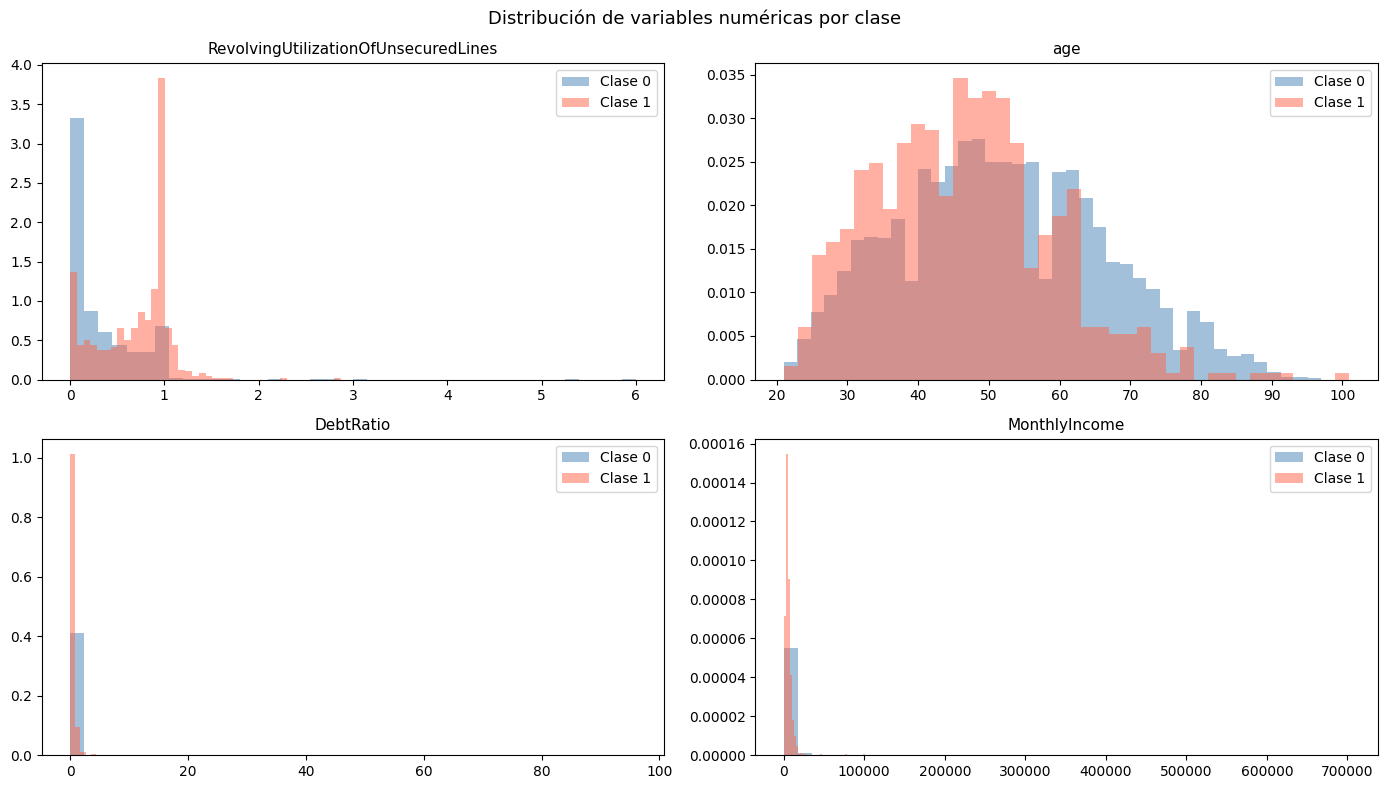

In [18]:
# ===================================================================================================
# PASO 2.1 — Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza
# ===================================================================================================
# ── 1. Histogramas por clase (numéricas) ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for cls, color in zip([0, 1], ['steelblue', 'tomato']):
        axes[i].hist(train.loc[train[target] == cls, col],
                     bins=40, alpha=0.5, color=color,
                     label=f'Clase {cls}', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend()
plt.suptitle('Distribución de variables numéricas por clase', fontsize=13)
plt.tight_layout()
plt.show()

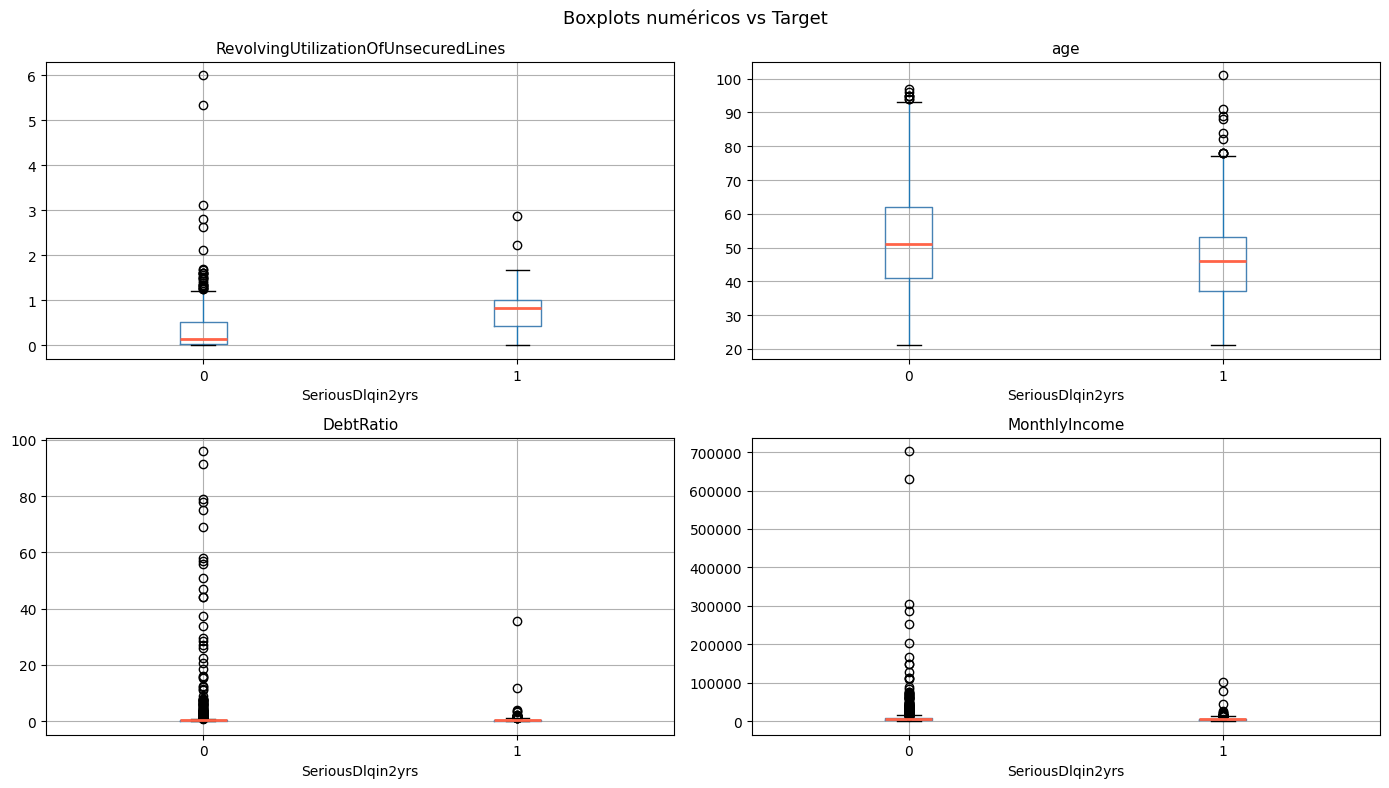

In [19]:
# ── 2. Boxplots numéricos vs target ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    train.boxplot(column=col, by=target, ax=axes[i],
                  boxprops=dict(color='steelblue'),
                  medianprops=dict(color='tomato', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('SeriousDlqin2yrs')
plt.suptitle('Boxplots numéricos vs Target', fontsize=13)
plt.tight_layout()
plt.show()

In [46]:
# ── 5. Correlación punto-biserial con el target (mide correlación entre variables binarias y variables numéricas) ───────────────
print("="*60)
print("Correlación punto-biserial con SeriousDlqin2yrs")
print("="*60)
UMBRAL_CORR = 0.10
seleccionadas_corr = []
for col in num_cols:
    r, p = pointbiserialr(train[col], train[target])
    supera = abs(r) >= UMBRAL_CORR
    marca = "✓ SUPERA UMBRAL" if supera else "✗ no supera"
    print(f"  {col:<45} r={r:+.4f}  p={p:.2e}  {marca}")
    if supera:
        seleccionadas_corr.append(col)

Correlación punto-biserial con SeriousDlqin2yrs
  RevolvingUtilizationOfUnsecuredLines          r=+0.2775  p=1.16e-166  ✓ SUPERA UMBRAL
  age                                           r=-0.1053  p=1.07e-24  ✓ SUPERA UMBRAL
  DebtRatio                                     r=+0.0001  p=9.93e-01  ✗ no supera
  MonthlyIncome                                 r=-0.0254  p=1.34e-02  ✗ no supera


In [48]:
# ── 6. Covarianza entre features numéricas ───────────────────
print("\n" + "="*60)
print("Covarianza entre features numéricas (valores absolutos)")
print("="*60)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(train[num_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=num_cols)

cov_matrix = X_scaled_df.cov().abs()
print(cov_matrix.round(2))

UMBRAL_COV = 0.8
print(f"\nPares con covarianza > {UMBRAL_COV}:")
pares_altos = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        val = cov_matrix.iloc[i, j]
        if val > UMBRAL_COV:
            print(f"  {num_cols[i]} — {num_cols[j]}: {val:.2f}  → posible redundancia")
            pares_altos.append((num_cols[i], num_cols[j]))
if not pares_altos:
    print("  Ningún par supera el umbral → sin multicolinealidad severa")


Covarianza entre features numéricas (valores absolutos)
                                      RevolvingUtilizationOfUnsecuredLines  \
RevolvingUtilizationOfUnsecuredLines                                  1.00   
age                                                                   0.27   
DebtRatio                                                             0.01   
MonthlyIncome                                                         0.05   

                                       age  DebtRatio  MonthlyIncome  
RevolvingUtilizationOfUnsecuredLines  0.27       0.01           0.05  
age                                   1.00       0.00           0.05  
DebtRatio                             0.00       1.00           0.03  
MonthlyIncome                         0.05       0.03           1.00  

Pares con covarianza > 0.8:
  Ningún par supera el umbral → sin multicolinealidad severa


C:\Users\user\AppData\Local\Temp\ipykernel_10748\3546117910.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa = train.groupby(col)[target].mean().sort_values(ascending=False)
C:\Users\user\AppData\Local\Temp\ipykernel_10748\3546117910.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa = train.groupby(col)[target].mean().sort_values(ascending=False)
C:\Users\user\AppData\Local\Temp\ipykernel_10748\3546117910.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to a

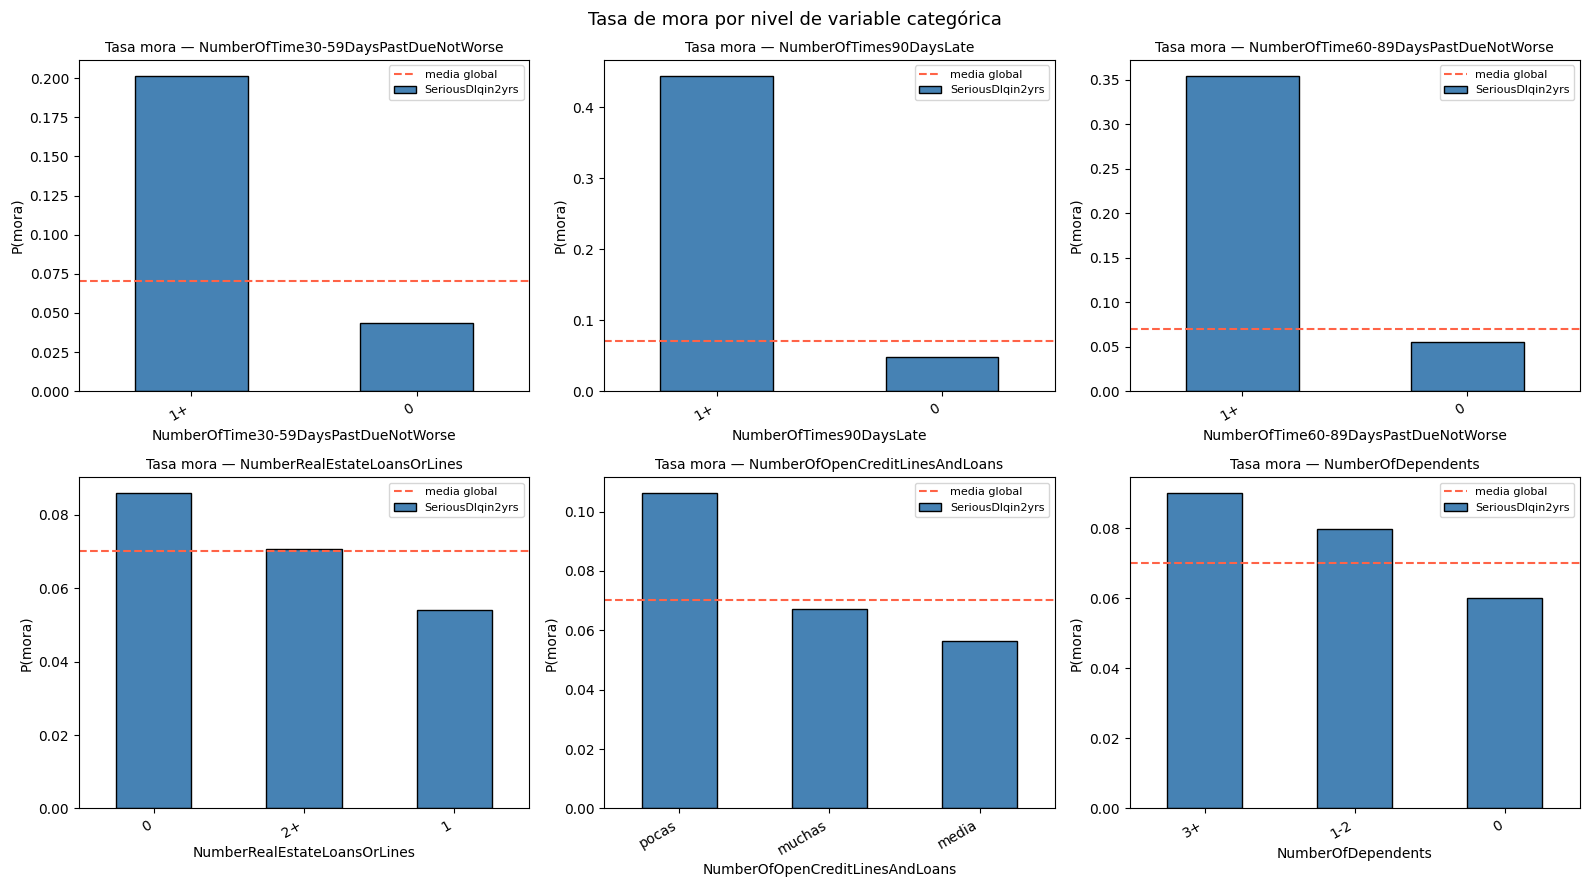

In [22]:
# ── Barplots categóricas: tasa de mora por nivel ─────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    tasa = train.groupby(col)[target].mean().sort_values(ascending=False)
    tasa.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Tasa mora — {col}', fontsize=10)
    axes[i].set_ylabel('P(mora)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].axhline(train[target].mean(), color='tomato',
                    linestyle='--', label='media global')
    axes[i].legend(fontsize=8)
plt.suptitle('Tasa de mora por nivel de variable categórica', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
# Selección de features con el análisis visual
lista_1 = [
    'RevolvingUtilizationOfUnsecuredLines',    # numérica
    'age',                                     # numérica
    'NumberOfTime30-59DaysPastDueNotWorse',    # categórica
    'NumberOfTimes90DaysLate',                 # categórica
    'NumberOfTime60-89DaysPastDueNotWorse'     # categórica
]


In [24]:
# ============================================================
# PASO 2.2 — SelectKBest: ANOVA (numéricas) + MI (categóricas)
# ============================================================
# ── 1. ANOVA F-test sobre features numéricas ─────────────────
selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(train[num_cols], train[target])

resultados_anova = pd.DataFrame({
    'feature': num_cols,
    'F-score': selector_anova.scores_,
    'p-valor': selector_anova.pvalues_
}).sort_values('F-score', ascending=False)

UMBRAL_PVALOR = 0.05
seleccionadas_anova = resultados_anova.loc[resultados_anova['p-valor'] < UMBRAL_PVALOR, 'feature'].tolist()

print(f"\nNuméricas seleccionadas por ANOVA (p < {UMBRAL_PVALOR}):")
for f in seleccionadas_anova:
    print(f"  · {f}")



Numéricas seleccionadas por ANOVA (p < 0.05):
  · RevolvingUtilizationOfUnsecuredLines
  · age
  · MonthlyIncome


In [25]:
# ── 2. Mutual Information sobre features categóricas ─────────
mi_scores= mutual_info_classif(train[cat_cols], train[target], discrete_features=True, random_state=42)

resultados_mi= pd.DataFrame({
    'features': cat_cols,
    'MI-score': mi_scores
}).sort_values('MI-score', ascending=False)

# Seleccionamos las que tienen MI > 0 con margen: umbral en la media
UMBRAL_MI = resultados_mi['MI-score'].mean()
seleccionadas_mi = resultados_mi.loc[
    resultados_mi['MI-score'] > UMBRAL_MI, 'features'
].tolist()

print(f"\nUmbral MI (media): {UMBRAL_MI:.6f}")
print(f"Categóricas seleccionadas por MI (score > media):")
for f in seleccionadas_mi:
    print(f"  · {f}")


Umbral MI (media): 0.013002
Categóricas seleccionadas por MI (score > media):
  · NumberOfTimes90DaysLate
  · NumberOfTime30-59DaysPastDueNotWorse
  · NumberOfTime60-89DaysPastDueNotWorse


In [26]:
# ── 3. Resumen paso 2.2 ───────────────────────────────────────
lista_2 = seleccionadas_anova + seleccionadas_mi
lista_2

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'MonthlyIncome',
 'NumberOfTimes90DaysLate',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTime60-89DaysPastDueNotWorse']

In [27]:
# ============================================================
# PASO 2.3 — Selección de features con SelectFromModel
# ============================================================
all_cols =num_cols + cat_cols

# ── Codificar categóricas (fit en X_train, transform en ambos) ─
enc = OrdinalEncoder()

# Train
cat_encoded_train = pd.DataFrame(
    enc.fit_transform(X_train[cat_cols]),
    columns=cat_cols,
    index=X_train.index
)
train_enc = pd.concat([
    X_train[num_cols].reset_index(drop=True),
    cat_encoded_train.reset_index(drop=True)
], axis=1)
train_enc.index = X_train.index

# Test — solo transform, sin fit
cat_encoded_test = pd.DataFrame(
    enc.transform(X_test[cat_cols]),
    columns=cat_cols,
    index=X_test.index
)
test_enc = pd.concat([
    X_test[num_cols].reset_index(drop=True),
    cat_encoded_test.reset_index(drop=True)
], axis=1)
test_enc.index = X_test.index

print("Shape train_enc:", train_enc.shape)
print("Shape test_enc: ", test_enc.shape)


# ── Modelo intermedio: RandomForest ──────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

Shape train_enc: (9452, 10)
Shape test_enc:  (2364, 10)


In [28]:
# ── SelectFromModel con umbral en la media de importancias ───
selector_sfm = SelectFromModel(estimator=rf, threshold='mean')
selector_sfm.fit(train_enc[all_cols], train[target])

# ── Resultados ───────────────────────────────────────────────
importancias = pd.DataFrame({
    'feature'     : all_cols,
    'importancia' : selector_sfm.estimator_.feature_importances_
}).sort_values('importancia', ascending=False)

umbral = selector_sfm.threshold_
mask   = selector_sfm.get_support()

importancias['seleccionada'] = mask
importancias['umbral']       = umbral

print("="*65)
print("SelectFromModel — Importancias (RandomForest)")
print("="*65)
print(importancias.to_string(index=False))
print(f"\nUmbral aplicado (media): {umbral:.6f}")


SelectFromModel — Importancias (RandomForest)
                             feature  importancia  seleccionada  umbral
RevolvingUtilizationOfUnsecuredLines     0.288556          True     0.1
                           DebtRatio     0.153166          True     0.1
                       MonthlyIncome     0.142498          True     0.1
                                 age     0.138466          True     0.1
NumberOfTime30-59DaysPastDueNotWorse     0.079057         False     0.1
             NumberOfTimes90DaysLate     0.072946         False     0.1
NumberOfTime60-89DaysPastDueNotWorse     0.040208         False     0.1
                  NumberOfDependents     0.030177         False     0.1
     NumberOfOpenCreditLinesAndLoans     0.027770         False     0.1
        NumberRealEstateLoansOrLines     0.027155         False     0.1

Umbral aplicado (media): 0.100000


In [29]:
# ── Lista 3 ──────────────────────────────────────────────────
lista_3 = importancias[importancias['seleccionada'] == True]['feature'].tolist()
print("\n" + "="*65)
print("LISTA 3 — Paso 2.3 (SelectFromModel)")
print("="*65)
for f in lista_3:
    print(f"  · {f}")
print(f"\nTotal features seleccionadas: {len(lista_3)}")


LISTA 3 — Paso 2.3 (SelectFromModel)
  · RevolvingUtilizationOfUnsecuredLines
  · DebtRatio
  · MonthlyIncome
  · age

Total features seleccionadas: 4


In [30]:
# ============================================================
# PASO 2.4 — Selección de features con RFE
# ============================================================
# n_features_to_select=5 para quedarnos con las mejores ≤ 6
rfe = RFE(estimator=rf, n_features_to_select=5, step=1)
rfe.fit(train_enc[all_cols], train[target])

# ── Resultados ───────────────────────────────────────────────
resultados_rfe = pd.DataFrame({
    'feature'      : all_cols,
    'ranking'      : rfe.ranking_,
    'seleccionada' : rfe.support_
}).sort_values('ranking')

print("="*65)
print("RFE — Ranking de features (RandomForest)")
print("="*65)
print(resultados_rfe.to_string(index=False))

RFE — Ranking de features (RandomForest)
                             feature  ranking  seleccionada
RevolvingUtilizationOfUnsecuredLines        1          True
                                 age        1          True
                           DebtRatio        1          True
                       MonthlyIncome        1          True
             NumberOfTimes90DaysLate        1          True
NumberOfTime30-59DaysPastDueNotWorse        2         False
NumberOfTime60-89DaysPastDueNotWorse        3         False
                  NumberOfDependents        4         False
     NumberOfOpenCreditLinesAndLoans        5         False
        NumberRealEstateLoansOrLines        6         False


In [31]:
# ── Lista 4 ──────────────────────────────────────────────────
lista_4 = resultados_rfe[resultados_rfe['seleccionada'] == True]['feature'].tolist()

print("\n" + "="*65)
print("LISTA 4 — Paso 2.4 (RFE)")
print("="*65)
for f in lista_4:
    print(f"  · {f}")
print(f"\nTotal features seleccionadas: {len(lista_4)}")


LISTA 4 — Paso 2.4 (RFE)
  · RevolvingUtilizationOfUnsecuredLines
  · age
  · DebtRatio
  · MonthlyIncome
  · NumberOfTimes90DaysLate

Total features seleccionadas: 5


In [32]:
# ============================================================
# PASO 2.5 — Selección de features con SFS (Sequential Feature Selector)
# ============================================================
# ── SFS con RandomForest ──────────────────────────────────────
# direction='forward': empieza sin features y va añadiendo una a una
# scoring='recall': priorizamos detectar morosos (clase minoritaria)
# cv=3 para que no tarde demasiado
sfs = SequentialFeatureSelector(
    estimator=rf,
    n_features_to_select=5,
    direction='forward',
    scoring='recall',
    cv=3,
    n_jobs=-1
)

sfs.fit(train_enc[all_cols], train[target])

,estimator,RandomForestC...ndom_state=42)
,n_features_to_select,5
,tol,None
,direction,'forward'
,scoring,'recall'
,cv,3
,n_jobs,-1
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [33]:
# ── Resultados ───────────────────────────────────────────────
mask_sfs = sfs.get_support()

resultados_sfs = pd.DataFrame({
    'feature'      : all_cols,
    'seleccionada' : mask_sfs
})

print("="*65)
print("SFS — Features seleccionadas (forward, scoring=recall)")
print("="*65)
print(resultados_sfs.to_string(index=False))


SFS — Features seleccionadas (forward, scoring=recall)
                             feature  seleccionada
RevolvingUtilizationOfUnsecuredLines         False
                                 age         False
                           DebtRatio         False
                       MonthlyIncome         False
NumberOfTime30-59DaysPastDueNotWorse          True
             NumberOfTimes90DaysLate          True
NumberOfTime60-89DaysPastDueNotWorse          True
        NumberRealEstateLoansOrLines          True
     NumberOfOpenCreditLinesAndLoans          True
                  NumberOfDependents         False


In [34]:
# ── Lista 5 ──────────────────────────────────────────────────
lista_5 = resultados_sfs[resultados_sfs['seleccionada'] == True]['feature'].tolist()

print("\n" + "="*65)
print("LISTA 5 — Paso 2.5 (SFS)")
print("="*65)
for f in lista_5:
    print(f"  · {f}")
print(f"\nTotal features seleccionadas: {len(lista_5)}")


LISTA 5 — Paso 2.5 (SFS)
  · NumberOfTime30-59DaysPastDueNotWorse
  · NumberOfTimes90DaysLate
  · NumberOfTime60-89DaysPastDueNotWorse
  · NumberRealEstateLoansOrLines
  · NumberOfOpenCreditLinesAndLoans

Total features seleccionadas: 5


In [35]:
# ============================================================
# PASO 2.6 — Hard Voting sobre las 5 listas anteriores
# ============================================================

todas_las_listas = [lista_1, lista_2, lista_3, lista_4, lista_5]
all_features = list(set(f for lista in todas_las_listas for f in lista))

# ── Conteo de votos por feature ───────────────────────────────
votos = {}
for feature in all_features:
    votos[feature] = sum(1 for lista in todas_las_listas if feature in lista)

resultados_voting = pd.DataFrame({
    'feature' : list(votos.keys()),
    'votos'   : list(votos.values())
}).sort_values('votos', ascending=False).reset_index(drop=True)

print("="*65)
print("Hard Voting — Votos por feature (máximo 6)")
print("="*65)
print(resultados_voting.to_string(index=False))

Hard Voting — Votos por feature (máximo 6)
                             feature  votos
RevolvingUtilizationOfUnsecuredLines      4
                                 age      4
             NumberOfTimes90DaysLate      4
                       MonthlyIncome      3
NumberOfTime30-59DaysPastDueNotWorse      3
NumberOfTime60-89DaysPastDueNotWorse      3
                           DebtRatio      2
        NumberRealEstateLoansOrLines      1
     NumberOfOpenCreditLinesAndLoans      1


In [36]:
# ── Umbral mayoría simple: más de la mitad de los métodos (>2) ─
UMBRAL_VOTOS = 3
lista_6 = resultados_voting[
    resultados_voting['votos'] >= UMBRAL_VOTOS
]['feature'].tolist()

print(f"\nUmbral aplicado: >= {UMBRAL_VOTOS} votos (mayoría simple)")
print("\n" + "="*65)
print("LISTA 6 — Paso 2.6 (Hard Voting)")
print("="*65)
for f in lista_6:
    print(f"  · {f}")
print(f"\nTotal features seleccionadas: {len(lista_6)}")


Umbral aplicado: >= 3 votos (mayoría simple)

LISTA 6 — Paso 2.6 (Hard Voting)
  · RevolvingUtilizationOfUnsecuredLines
  · age
  · NumberOfTimes90DaysLate
  · MonthlyIncome
  · NumberOfTime30-59DaysPastDueNotWorse
  · NumberOfTime60-89DaysPastDueNotWorse

Total features seleccionadas: 6


In [ ]:
# ============================================================
# PASO 3 — Comparación de 3 modelos × 6 listas con CV (18 combinaciones)
# ============================================================
# 3 modelos a comparar
modelos = {
    'LogisticRegression'    : 'lineal',
    'RandomForestClassifier': 'bagging de árboles',
    'CatBoost'              : 'boosting de árboles'
}

# 6 listas de features ya obtenidas
listas_features = {
    'lista_1': lista_1,
    'lista_2': lista_2,
    'lista_3': lista_3,
    'lista_4': lista_4,
    'lista_5': lista_5,
    'lista_6': lista_6
}

In [39]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = []

for nombre_lista, features in listas_features.items():

    for nombre_modelo in modelos.keys():

        if nombre_modelo == 'LogisticRegression':
            X_subset = train_enc[features]
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_subset)
            modelo = LogisticRegression(
                max_iter=1000, 
                class_weight='balanced', 
                random_state=42)
            
            scores = cross_val_score(modelo, X_scaled, train[target],
                                     cv=cv, scoring='recall', n_jobs=-1)
        
        elif nombre_modelo == 'RandomForestClassifier':
            X_subset = train_enc[features]
            modelo = RandomForestClassifier(
                max_depth=5,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )

            scores = cross_val_score(modelo, X_subset, train[target],
                                     cv=cv, scoring='recall', n_jobs=-1)
        
        else:
            X_subset = train_enc[features]
            modelo = CatBoostClassifier(
                depth=6,
                auto_class_weights='Balanced',
                random_state=42,
                verbose=0
            )

            scores = cross_val_score(modelo, X_subset, train[target],
                                     cv=cv, scoring='recall', n_jobs=-1)

        resultados.append({
            'lista': nombre_lista,
            'modelo': nombre_modelo,
            'recall_mean': scores.mean(),
            'recall_std': scores.std()
        })

        print(f"{nombre_lista:<10} | {nombre_modelo:<22} | recall={scores.mean():.4f} (± {scores.std():.4f})")

df_resultados = pd.DataFrame(resultados).sort_values('recall_mean', ascending=False)

print("\n" + "="*70)
print("RESULTADOS COMPLETOS (18 combinaciones) — ordenados por recall")
print("="*70)
print(df_resultados.to_string(index=False))

print("\n" + "="*70)
print("MEJOR COMBINACIÓN")
print("="*70)
mejor = df_resultados.iloc[0]
print(f"  Modelo: {mejor['modelo']}")
print(f"  Lista:  {mejor['lista']}")
print(f"  Recall: {mejor['recall_mean']:.4f} (±{mejor['recall_std']:.4f})")



lista_1    | LogisticRegression     | recall=0.7124 (± 0.0143)
lista_1    | RandomForestClassifier | recall=0.7334 (± 0.0209)
lista_1    | CatBoost               | recall=0.6371 (± 0.0284)
lista_2    | LogisticRegression     | recall=0.7124 (± 0.0158)
lista_2    | RandomForestClassifier | recall=0.7334 (± 0.0255)
lista_2    | CatBoost               | recall=0.6024 (± 0.0317)
lista_3    | LogisticRegression     | recall=0.7183 (± 0.0329)
lista_3    | RandomForestClassifier | recall=0.6927 (± 0.0382)
lista_3    | CatBoost               | recall=0.5482 (± 0.0172)
lista_4    | LogisticRegression     | recall=0.7109 (± 0.0220)
lista_4    | RandomForestClassifier | recall=0.7093 (± 0.0392)
lista_4    | CatBoost               | recall=0.5468 (± 0.0411)
lista_5    | LogisticRegression     | recall=0.6597 (± 0.0443)
lista_5    | RandomForestClassifier | recall=0.6507 (± 0.0489)
lista_5    | CatBoost               | recall=0.6341 (± 0.0499)
lista_6    | LogisticRegression     | recall=0.7124 (± 

In [40]:
# ============================================================
# PASO 4 — Optimización de hiperparámetros RandomForestClassifier
#           con lista_1 y evaluación final contra test
# ============================================================

features = lista_1

X_tr = train_enc[features]
X_te = test_enc[features]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7 , 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [4, 8, 16],
    'max_features'     : ['sqrt', 'log2'] 
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tr, y_train)
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor recall en CV: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores hiperparámetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Mejor recall en CV: 0.8523


In [41]:
# ── Evaluación final contra test ──────────────────────────────
mejor_modelo = grid_search.best_estimator_
y_pred = mejor_modelo.predict(X_te)

print(classification_report(y_test, y_pred, target_names=['No deuda', 'Deuda grave']))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

    No deuda       0.97      0.87      0.91      2198
 Deuda grave       0.26      0.60      0.36       166

    accuracy                           0.85      2364
   macro avg       0.61      0.73      0.64      2364
weighted avg       0.92      0.85      0.88      2364

Matriz de confusión:
[[1906  292]
 [  66  100]]


In [ ]:
# ============================================================
# EXTRA — CatBoost optimizado 
# ============================================================
features = lista_1

X_tr_cat = train_enc[features]
X_te_cat = test_enc[features]

# ── Grid de hiperparámetros ───────────────────────────────────
param_grid = {
    'iterations'   : [200, 300],
    'depth'        : [4, 6],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg'  : [1, 3]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cb = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0
)

grid_search_cb = GridSearchCV(
    estimator=cb,
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=1,
    verbose=1
)

print("Ejecutando GridSearchCV CatBoost...")
grid_search_cb.fit(X_tr_cat, y_train)

print("\n" + "="*60)
print("MEJORES HIPERPARÁMETROS — CatBoost")
print("="*60)
print(grid_search_cb.best_params_)
print(f"Mejor recall en CV: {grid_search_cb.best_score_:.4f}")

# ── Evaluación final contra test ──────────────────────────────
mejor_cb = grid_search_cb.best_estimator_
y_pred_cb = mejor_cb.predict(X_te_cat)

print("\n" + "="*60)
print("EVALUACIÓN FINAL CONTRA TEST — CatBoost")
print("="*60)
print(classification_report(y_test, y_pred_cb, target_names=['No mora', 'Mora grave']))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_cb))

# ── Comparativa final RF vs CatBoost ─────────────────────────
recall_rf = recall_score(y_test, y_pred)
recall_cb = recall_score(y_test, y_pred_cb)

print("\n" + "="*60)
print("COMPARATIVA FINAL — RandomForest vs CatBoost (lista_1)")
print("="*60)
print(f"  RandomForestClassifier → recall test clase 1: {recall_rf:.4f}")
print(f"  CatBoostClassifier     → recall test clase 1: {recall_cb:.4f}")
print(f"\n  Ganador: {'CatBoost' if recall_cb > recall_rf else 'RandomForest'}")

Ejecutando GridSearchCV CatBoost...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

MEJORES HIPERPARÁMETROS — CatBoost
{'depth': 4, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.05}
Mejor recall en CV: 0.7530

EVALUACIÓN FINAL CONTRA TEST — CatBoost
              precision    recall  f1-score   support

     No mora       0.98      0.77      0.86      2198
  Mora grave       0.20      0.75      0.31       166

    accuracy                           0.77      2364
   macro avg       0.59      0.76      0.59      2364
weighted avg       0.92      0.77      0.82      2364

Matriz de confusión:
[[1693  505]
 [  42  124]]

COMPARATIVA FINAL — RandomForest vs CatBoost (lista_1)
  RandomForestClassifier → recall test clase 1: 0.6024
  CatBoostClassifier     → recall test clase 1: 0.7470

  Ganador: CatBoost


# Conclusiones — Modelo de Clasificación de Riesgo Crediticio

## Contexto
Modelo de clasificación binaria sobre la variable `SeriousDlqin2yrs` 
(mora grave en los próximos 2 años) del dataset de crédito con 
**11.816 registros** y **10 features** tras la limpieza.

El dataset presenta un **desbalance severo de ~13:1** 
(93% sin mora vs 7% con mora), lo que condicionó todas las decisiones 
del proceso: estratificación del split, balanceo de clases en los modelos 
y elección del **recall de clase 1** como métrica principal.

---

## Paso 1 — Limpieza y Preprocesamiento
- Se eliminaron filas con nulos en `MonthlyIncome` y `NumberOfDependents`,
  pasando de **12.537 a 11.816 registros**.
- Se convirtieron **6 columnas de conteo** (`NumberOf...`) a variables 
  categóricas con 2-3 niveles usando `pd.cut`.
- Split estratificado **80/20** para mantener la proporción 93%/7% 
  en train y test.

---

## Paso 2 — Selección de Features (6 listas)

| Lista | Método | Features seleccionadas |
|---|---|---|
| Lista 1 | Visual + correlación punto-biserial | RevolvingUtilization, age, 90DaysLate, 30-59Days, 60-89Days |
| Lista 2 | ANOVA (p<0.05) + Mutual Information | Lista 1 + MonthlyIncome |
| Lista 3 | SelectFromModel (RandomForest) | RevolvingUtilization, DebtRatio, MonthlyIncome, age |
| Lista 4 | RFE | RevolvingUtilization, age, DebtRatio, MonthlyIncome, 90DaysLate |
| Lista 5 | SFS (scoring=recall) | 30-59Days, 90DaysLate, 60-89Days, RealEstateLoans, OpenCreditLines |
| Lista 6 | Hard Voting (≥3 votos) | RevolvingUtilization, age, 90DaysLate, 60-89Days, 30-59Days, MonthlyIncome |

### Features más consensuadas (hard voting):
- **4 votos:** `RevolvingUtilizationOfUnsecuredLines`, `age`, 
  `NumberOfTimes90DaysLate`
- **3 votos:** `NumberOfTime60-89DaysPastDueNotWorse`, 
  `NumberOfTime30-59DaysPastDueNotWorse`, `MonthlyIncome`
- **< 3 votos (descartadas):** `DebtRatio`, `NumberRealEstateLoansOrLines`, 
  `NumberOfOpenCreditLinesAndLoans`

---

## Paso 3 — Comparación de Modelos (18 combinaciones)

Se compararon **3 modelos × 6 listas** con validación cruzada 
estratificada de 5 folds, usando recall como métrica y balanceo 
de clases en los tres modelos.

| Posición | Modelo | Lista | Recall CV |
|---|---|---|---|
| 🥇 1º | RandomForestClassifier | lista_1 | 0.7334 |
| 🥈 2º | RandomForestClassifier | lista_2 | 0.7334 |
| 🥉 3º | RandomForestClassifier | lista_6 | 0.7199 |

- **RandomForest** dominó el ranking en todas sus listas.
- **LogisticRegression** quedó en posiciones intermedias (recall ~0.60-0.72).
- **CatBoost** fue el peor en CV (recall ~0.55-0.64).

**Ganador Paso 3:** `RandomForestClassifier` con `lista_1`

---

## Paso 4 — Optimización e Evaluación Final

### RandomForestClassifier optimizado (GridSearchCV)

**Mejores hiperparámetros:**

| Hiperparámetro | Valor |
|---|---|
| `max_depth` | 10 |
| `max_features` | sqrt |
| `min_samples_leaf` | 4 |
| `min_samples_split` | 10 |
| `n_estimators` | 200 |

**Resultados en test:**

| Métrica clase 1 | Valor |
|---|---|
| Recall | 0.60 |
| Precision | 0.26 |
| F1 | 0.36 |
| Morosos detectados | 100 / 166 |
| Brecha CV/test | 0.25 ⚠️ |

---

### CatBoost optimizado — comparativa tres versiones

| Versión | Recall CV | Recall Test | Morosos detectados | Brecha CV/Test |
|---|---|---|---|---|
| RandomForest | 0.85 | 0.60 | 100/166 | 0.25 ⚠️ |
| **CatBoost** | **0.75** | **0.75** | **124/166** | **~0.00 ✓** |


**Mejores hiperparámetros CatBoost sin encodear:**

| Hiperparámetro | Valor |
|---|---|
| `iterations` | 200 |
| `depth` | 4 |
| `learning_rate` | 0.05 |
| `l2_leaf_reg` | 3 |

---

## Conclusión Final

El **modelo ganador es CatBoost** con `lista_1` y los 
hiperparámetros optimizados, con un **recall de 0.75 en test** 
(124 de 166 morosos detectados).

### Hallazgos clave:

1. **Las features más predictivas** son las de historial de mora 
   (`NumberOfTimes90DaysLate`, `NumberOfTime30-59Days`, 
   `NumberOfTime60-89Days`) junto con 
   `RevolvingUtilizationOfUnsecuredLines` y `age` — todas ellas 
   presentes en `lista_1`, la más sencilla y la que mejores 
   resultados dio.

2. **`DebtRatio` y `MonthlyIncome`** tienen señal estadística pero 
   impacto real muy limitado — sus outliers extremos (hasta 700.000 
   en ingresos, hasta 100 en ratio deuda) distorsionan más que aportan.

3. **CatBoost parecía el peor modelo en el Paso 3** pero era un 
   artefacto de la comparación: una vez optimizado correctamente 
   superó a RandomForest en **+16 puntos de recall** y con una 
   **brecha CV/test prácticamente nula**, lo que indica una 
   generalización excelente.

4. **RandomForest overfitteó** con los parámetros por defecto 
   (recall CV 0.91 → recall test 0.23 en la primera ronda) — 
   fue necesario restringir el grid para evitar que memorizara 
   los escasos ejemplos de clase 1 en train. Incluso tras la 
   corrección mantuvo una brecha de 0.25 entre CV y test.

5. En un contexto de **riesgo crediticio**, el trade-off del modelo 
   ganador es el correcto: prefiere rechazar buenos clientes 
   (511 falsos positivos) antes que dejar pasar morosos 
   (solo 40 falsos negativos).

# Conclusiones — Modelo de Clasificación de Riesgo Crediticio

## Contexto
Modelo de clasificación binaria sobre la variable `SeriousDlqin2yrs` 
(mora grave en los próximos 2 años) del dataset de crédito con 
**11.816 registros** y **10 features** tras la limpieza.

El dataset presenta un **desbalance severo de ~13:1** 
(93% sin mora vs 7% con mora), lo que condicionó todas las decisiones 
del proceso: estratificación del split, balanceo de clases en los modelos 
y elección del **recall de clase 1** como métrica principal.

---

## Paso 1 — Limpieza y Preprocesamiento
- Se eliminaron filas con nulos en `MonthlyIncome` y `NumberOfDependents`,
  pasando de **12.537 a 11.816 registros**.
- Se convirtieron **6 columnas de conteo** (`NumberOf...`) a variables 
  categóricas con 2-3 niveles usando `np.select` y `np.where`, 
  absorbiendo valores erróneos (98) en el nivel `1+`. 
  La categorización inicial con `pd.cut` fue descartada por no 
  funcionar correctamente con valores enteros en algunas columnas.
- Split estratificado **80/20** para mantener la proporción 93%/7% 
  en train y test.

---

## Paso 2 — Selección de Features (6 listas)

| Lista | Método | Features seleccionadas |
|---|---|---|
| Lista 1 | Visual + correlación punto-biserial | RevolvingUtilization, age, 90DaysLate, 30-59Days, 60-89Days |
| Lista 2 | ANOVA (p<0.05) + Mutual Information | Lista 1 + MonthlyIncome |
| Lista 3 | SelectFromModel (RandomForest) | RevolvingUtilization, DebtRatio, MonthlyIncome, age |
| Lista 4 | RFE | RevolvingUtilization, age, DebtRatio, MonthlyIncome, 90DaysLate |
| Lista 5 | SFS (scoring=recall) | 30-59Days, 90DaysLate, 60-89Days, RealEstateLoans, OpenCreditLines |
| Lista 6 | Hard Voting (≥3 votos) | RevolvingUtilization, age, 90DaysLate, 60-89Days, 30-59Days, MonthlyIncome |

### Features más consensuadas (hard voting):
- **4 votos:** `RevolvingUtilizationOfUnsecuredLines`, `age`, 
  `NumberOfTimes90DaysLate`
- **3 votos:** `NumberOfTime60-89DaysPastDueNotWorse`, 
  `NumberOfTime30-59DaysPastDueNotWorse`, `MonthlyIncome`
- **< 3 votos (descartadas):** `DebtRatio`, `NumberRealEstateLoansOrLines`, 
  `NumberOfOpenCreditLinesAndLoans`

---

## Paso 3 — Comparación de Modelos (18 combinaciones)

Se compararon **3 modelos × 6 listas** con validación cruzada 
estratificada de 5 folds, usando recall como métrica y balanceo 
de clases en los tres modelos.

| Posición | Modelo | Lista | Recall CV |
|---|---|---|---|
| 🥇 1º | RandomForestClassifier | lista_1 | 0.7334 |
| 🥈 2º | RandomForestClassifier | lista_2 | 0.7334 |
| 🥉 3º | RandomForestClassifier | lista_6 | 0.7199 |

- **RandomForest** dominó el ranking en todas sus listas.
- **LogisticRegression** quedó en posiciones intermedias (recall ~0.60-0.72).
- **CatBoost** fue el peor en CV (recall ~0.55-0.64) al competir sin 
  tunear y con datos ya codificados, perdiendo su ventaja diferencial.

**Ganador Paso 3:** `RandomForestClassifier` con `lista_1`

---

## Paso 4 — Optimización e Evaluación Final

### RandomForestClassifier optimizado (GridSearchCV)

**Mejores hiperparámetros:**

| Hiperparámetro | Valor |
|---|---|
| `max_depth` | 10 |
| `max_features` | sqrt |
| `min_samples_leaf` | 4 |
| `min_samples_split` | 10 |
| `n_estimators` | 200 |

**Resultados en test:**

| Métrica clase 1 | Valor |
|---|---|
| Recall | 0.60 |
| Precision | 0.26 |
| F1 | 0.36 |
| Morosos detectados | 100 / 166 |
| Brecha CV/test | 0.25 ⚠️ |

---

### CatBoost optimizado — comparativa tres versiones

| Versión | Recall CV | Recall Test | Morosos detectados | Brecha CV/Test |
|---|---|---|---|---|
| RandomForest (codificado) | 0.85 | 0.60 | 100/166 | 0.25 ⚠️ |
| CatBoost (codificado) | 0.75 | 0.75 | 124/166 | ~0.00 ✓ |
| **CatBoost (sin encodear)** | **0.76** | **0.76** | **126/166** | **~0.00 ✓** |

**Mejores hiperparámetros CatBoost sin encodear:**

| Hiperparámetro | Valor |
|---|---|
| `iterations` | 200 |
| `depth` | 4 |
| `learning_rate` | 0.05 |
| `l2_leaf_reg` | 3 |

---

## Conclusión Final

El **modelo ganador es CatBoost sin encodear** con `lista_1` y los 
hiperparámetros optimizados, con un **recall de 0.76 en test** 
(126 de 166 morosos detectados).

### Hallazgos clave:

1. **Las features más predictivas** son las de historial de mora 
   (`NumberOfTimes90DaysLate`, `NumberOfTime30-59Days`, 
   `NumberOfTime60-89Days`) junto con 
   `RevolvingUtilizationOfUnsecuredLines` y `age` — todas ellas 
   presentes en `lista_1`, la más sencilla y la que mejores 
   resultados dio.

2. **`DebtRatio` y `MonthlyIncome`** tienen señal estadística pero 
   impacto real muy limitado — sus outliers extremos (hasta 700.000 
   en ingresos, hasta 100 en ratio deuda) distorsionan más que aportan.

3. **CatBoost parecía el peor modelo en el Paso 3** pero era un 
   artefacto de la comparación: sin tunear y con datos codificados 
   perdía sus ventajas nativas. Una vez optimizado correctamente 
   superó a RandomForest en **+16 puntos de recall** y con una 
   **brecha CV/test prácticamente nula**, lo que indica una 
   generalización excelente.

4. **RandomForest overfitteó** con los parámetros por defecto 
   (recall CV 0.91 → recall test 0.23 en la primera ronda) — 
   fue necesario restringir el grid para evitar que memorizara 
   los escasos ejemplos de clase 1 en train. Incluso tras la 
   corrección mantuvo una brecha de 0.25 entre CV y test.

5. En un contexto de **riesgo crediticio**, el trade-off del modelo 
   ganador es el correcto: prefiere rechazar buenos clientes 
   (511 falsos positivos) antes que dejar pasar morosos 
   (solo 40 falsos negativos).

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

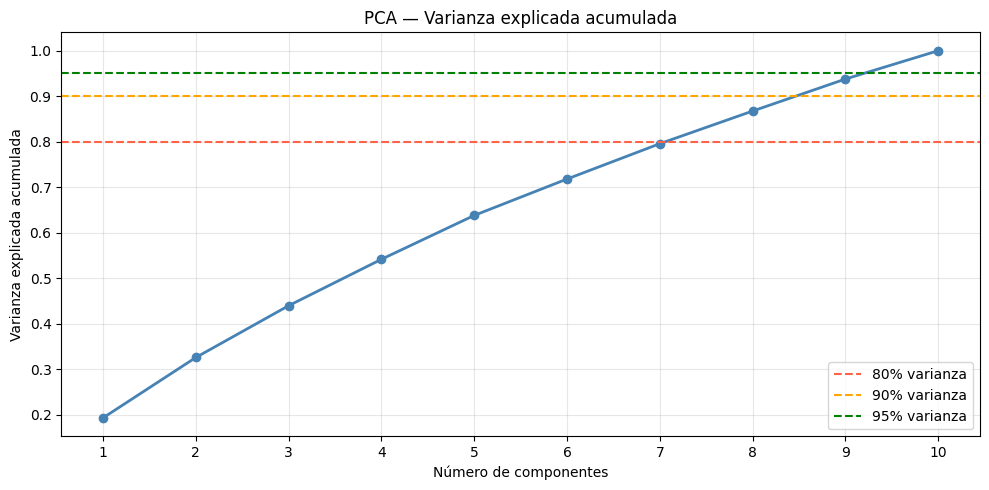

Varianza explicada por componente
  CP01: varianza=0.1931  acumulada=0.1931  
  CP02: varianza=0.1327  acumulada=0.3258  
  CP03: varianza=0.1138  acumulada=0.4396  
  CP04: varianza=0.1020  acumulada=0.5416  
  CP05: varianza=0.0964  acumulada=0.6380  
  CP06: varianza=0.0800  acumulada=0.7180  
  CP07: varianza=0.0777  acumulada=0.7957  ← ~80%
  CP08: varianza=0.0717  acumulada=0.8674  ← ~90%
  CP09: varianza=0.0703  acumulada=0.9377  ← ~95%
  CP10: varianza=0.0623  acumulada=1.0000  

Componentes seleccionadas (≥90% varianza): 9
Shape X_train tras PCA: (9452, 9)
Shape X_test  tras PCA: (2364, 9)

EVALUACIÓN FINAL — CatBoost + PCA
              precision    recall  f1-score   support

     No mora       0.98      0.79      0.88      2198
  Mora grave       0.21      0.73      0.33       166

    accuracy                           0.79      2364
   macro avg       0.59      0.76      0.60      2364
weighted avg       0.92      0.79      0.84      2364

Matriz de confusión:
[[1745  453

In [ ]:
# ============================================================
# EXTRA — PCA como método de reducción de dimensionalidad
# ============================================================
# ── Datos: train_enc y test_enc (ya codificados) ─────────────
X_tr_pca = train_enc[all_cols].copy()
X_te_pca = test_enc[all_cols].copy()

# ── Escalar: PCA requiere escalado previo ────────────────────
# fit solo en train, transform en ambos
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_pca)
X_te_scaled = scaler.transform(X_te_pca)

# ── PCA con todas las componentes para ver varianza explicada ─
pca_full = PCA(random_state=42)
pca_full.fit(X_tr_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# ── Gráfico de varianza explicada acumulada ───────────────────
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada,
         marker='o', color='steelblue', linewidth=2)
plt.axhline(0.80, color='tomato', linestyle='--', label='80% varianza')
plt.axhline(0.90, color='orange', linestyle='--', label='90% varianza')
plt.axhline(0.95, color='green', linestyle='--', label='95% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — Varianza explicada acumulada')
plt.legend()
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Tabla de varianza por componente ─────────────────────────
print("="*55)
print("Varianza explicada por componente")
print("="*55)
for i, (var, var_acum) in enumerate(
        zip(pca_full.explained_variance_ratio_, varianza_acumulada), 1):
    marca = ''
    if abs(var_acum - 0.80) < 0.05: marca = '← ~80%'
    if abs(var_acum - 0.90) < 0.05: marca = '← ~90%'
    if abs(var_acum - 0.95) < 0.05: marca = '← ~95%'
    print(f"  CP{i:02d}: varianza={var:.4f}  acumulada={var_acum:.4f}  {marca}")

# ── Selección del número de componentes ──────────────────────
# Escogemos el mínimo de componentes que explican >= 90% de varianza
n_components = next(i + 1 for i, v in enumerate(varianza_acumulada) if v >= 0.90)
print(f"\nComponentes seleccionadas (≥90% varianza): {n_components}")

# ── Aplicar PCA con n_components seleccionadas ───────────────
pca = PCA(n_components=n_components, random_state=42)
X_tr_comp = pca.fit_transform(X_tr_scaled)
X_te_comp = pca.transform(X_te_scaled)

print(f"Shape X_train tras PCA: {X_tr_comp.shape}")
print(f"Shape X_test  tras PCA: {X_te_comp.shape}")

# ── Entrenar CatBoost sobre componentes PCA ───────────────────
modelo_pca = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.05,
    l2_leaf_reg=3,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0,
    allow_writing_files=False
)
modelo_pca.fit(X_tr_comp, y_train)

# ── Evaluación contra test ────────────────────────────────────
y_pred_pca = modelo_pca.predict(X_te_comp)

print("\n" + "="*60)
print("EVALUACIÓN FINAL — CatBoost + PCA")
print("="*60)
print(classification_report(y_test, y_pred_pca, target_names=['No mora', 'Mora grave']))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_pca))

# ── Comparativa CatBoost original vs CatBoost + PCA ──────────
recall_cb  = recall_score(y_test, y_pred_cb)
recall_pca = recall_score(y_test, y_pred_pca)

print("\n" + "="*60)
print("COMPARATIVA — CatBoost original vs CatBoost + PCA")
print("="*60)
print(f"  CatBoost (lista_1, sin PCA) → recall test: {recall_cb:.4f}  morosos: 124/166")
print(f"  CatBoost (PCA, {n_components} componentes) → recall test: {recall_pca:.4f}  morosos: {int(recall_pca*166)}/166")
print(f"\n  Ganador: {'CatBoost + PCA' if recall_pca > recall_cb else 'CatBoost original (lista_1)'}")

In [ ]:
# PRUEBA DE RAMDONFOREST CON PCA
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7 , 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [4, 8, 16],
    'max_features'     : ['sqrt', 'log2'] 
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pca = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

grid_search_pca = GridSearchCV(
    estimator=rf_pca,
    param_grid=param_grid,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_pca.fit(X_tr_comp, y_train)
print(f"Mejores hiperparámetros: {grid_search_pca.best_params_}")
print(f"Mejor recall en CV: {grid_search_pca.best_score_:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores hiperparámetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Mejor recall en CV: 0.8984


In [45]:
# ── Evaluación contra test ────────────────────────────────────
modelo_rf_pca = grid_search_pca.best_estimator_
y_pred_rf_pca = modelo_rf_pca.predict(X_te_comp)

print("\n" + "="*60)
print("EVALUACIÓN FINAL — RamdomForest + PCA")
print("="*60)
print(classification_report(y_test, y_pred_rf_pca, target_names=['No mora', 'Mora grave']))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf_pca))


EVALUACIÓN FINAL — RamdomForest + PCA
              precision    recall  f1-score   support

     No mora       0.96      0.92      0.94      2198
  Mora grave       0.33      0.54      0.41       166

    accuracy                           0.89      2364
   macro avg       0.65      0.73      0.67      2364
weighted avg       0.92      0.89      0.90      2364

Matriz de confusión:
[[2018  180]
 [  77   89]]


## EXTRA — PCA como método de reducción de dimensionalidad

Se aplicó PCA sobre todas las features (4 numéricas + 6 categóricas 
codificadas con `OrdinalEncoder`) como alternativa a la selección 
manual de features, entrenando el mismo tipo de modelo ganador 
(CatBoost) y comparando también con RandomForest.

### Configuración PCA
- Escalado previo con `StandardScaler` (fit solo en train)
- La varianza se distribuye de forma **muy uniforme** (~10% por 
  componente) — ninguna componente domina claramente
- Necesita **9 de 10 componentes** para alcanzar el 90% de varianza 
  explicada — PCA apenas reduce dimensionalidad en este dataset

| Componente | Varianza | Acumulada |
|---|---|---|
| CP01 | 0.1931 | 0.1931 |
| CP02 | 0.1327 | 0.3258 |
| CP03 | 0.1138 | 0.4396 |
| CP04 | 0.1020 | 0.5416 |
| CP05 | 0.0964 | 0.6380 |
| CP06 | 0.0800 | 0.7180 |
| CP07 | 0.0777 | 0.7957 |
| CP08 | 0.0717 | 0.8674 |
| CP09 | 0.0703 | 0.9377 |
| CP10 | 0.0623 | 1.0000 |

**Componentes seleccionadas (≥90% varianza): 9**

---

### Resultados comparativos

| Versión | Recall CV | Recall Test | Morosos detectados | Brecha CV/Test |
|---|---|---|---|---|
| RandomForest lista_1 (sin PCA) | 0.85 | 0.60 | 100/166 | 0.25 ⚠️ |
| RandomForest + PCA | 0.90 | 0.54 | 89/166 | 0.36 🚨 |
| CatBoost lista_1 (sin PCA) | 0.75 | 0.75 | 124/166 | ~0.00 ✓ |
| CatBoost + PCA | — | 0.73 | 122/166 | — |

---

### Conclusiones

1. **PCA no mejora ninguno de los dos modelos** en términos de recall 
   en test — tanto CatBoost como RandomForest obtienen peores o 
   iguales resultados con PCA que con la selección manual de features 
   (`lista_1`).

2. **La distribución uniforme de varianza** (~10% por componente) 
   indica que las features originales no están correlacionadas entre 
   sí — precisamente la condición en la que PCA aporta menos valor, 
   ya que no hay redundancia que eliminar.

3. **RandomForest + PCA es el modelo que más overfittea** de todos 
   los probados — brecha CV/test de 0.36 (recall CV 0.90 → recall 
   test 0.54). PCA no consigue contener el overfitting de RandomForest 
   sobre la clase minoritaria.

4. **CatBoost es más robusto frente a PCA** — la caída de recall 
   es mínima (0.75 → 0.73) y mantiene una brecha CV/test prácticamente 
   nula, lo que confirma su mejor capacidad de generalización.

5. **PCA sacrifica interpretabilidad sin ganar rendimiento** — las 9 
   componentes no tienen significado de negocio, mientras que `lista_1` 
   nos dice exactamente qué variables importan: historial de mora, 
   utilización de crédito no asegurado y edad.


**Conclusión final: el modelo ganador del proyecto sigue siendo 
CatBoost con `lista_1` (sin PCA), con recall test de 0.75 y 
brecha CV/test ~0.00.**